In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from difflib import get_close_matches
from nba_api.stats.endpoints.drafthistory import DraftHistory
import requests

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import seaborn as sns

In [23]:
def get_draft_data(year):
    draft = DraftHistory(season_year_nullable=year, league_id='10')
    return draft.get_data_frames()[0]

def get_team_stats(compid):
    url = f'https://api.cbbanalytics.com/api/gs/team-agg-stats/competition/{compid}/division/1/scope/season/'
    df = pd.DataFrame(requests.get(url).json())
    df['fullName'] = df['teamMarket'] + ' ' + df['teamName'] + " Women's"
    return df

def best_match(name, api_names):
    if name in api_names:
        return name
    m = get_close_matches(name, api_names, n=1, cutoff=0.6)
    return m[0] if m else None

def merge_team_stats(player_df, team_df, cols):
    api_names = team_df['fullName'].tolist()
    team_map = {t: best_match(t, api_names) for t in player_df['Team'].unique()}
    out = player_df.copy()
    out['_team_key'] = out['Team'].map(team_map)
    team_dedup = (team_df[team_df['isOffense'] == True][cols]
                  .drop_duplicates(subset='fullName'))
    out = pd.merge(out, team_dedup, left_on='_team_key', right_on='fullName', how='left')
    out = out.drop(columns=['_team_key', 'fullName'])
    unmatched = [t for t, v in team_map.items() if v is None]
    if unmatched:
        print(f'Unmatched teams ({len(unmatched)}): {unmatched[:5]}')
    return out

In [24]:
draft_2025_df = get_draft_data(2025)
drafted_players_2025 = set(draft_2025_df['PLAYER_NAME'].unique())
print(f'2025 WNBA draftees: {len(drafted_players_2025)}')

player_stats_2025 = pd.read_csv('./data/Copy of WBB Data - ncaa_2425.csv')
player_stats_2025 = player_stats_2025[player_stats_2025['Class'] == 'SR'].copy()
player_stats_2025['Drafted'] = player_stats_2025['Player'].apply(
    lambda x: 1 if x in drafted_players_2025 else 0
)
print(f'Drafted players matched in stats: {player_stats_2025["Drafted"].sum()} / {len(drafted_players_2025)}')
not_found = drafted_players_2025 - set(player_stats_2025['Player'])
if not_found:
    print(f'Not found in stats (name mismatch or not SR): {not_found}')

team_stats_2025 = get_team_stats(38529)
player_stats_2025 = merge_team_stats(player_stats_2025, team_stats_2025, ['fullName', 'sos'])

2025 WNBA draftees: 38
Drafted players matched in stats: 33 / 38
Not found in stats (name mismatch or not SR): {'Anastasiia Olairi Kosu', 'Adja Kane', 'Ajsa Sivka', 'Dominique Malonga', 'Juste Jocyte'}


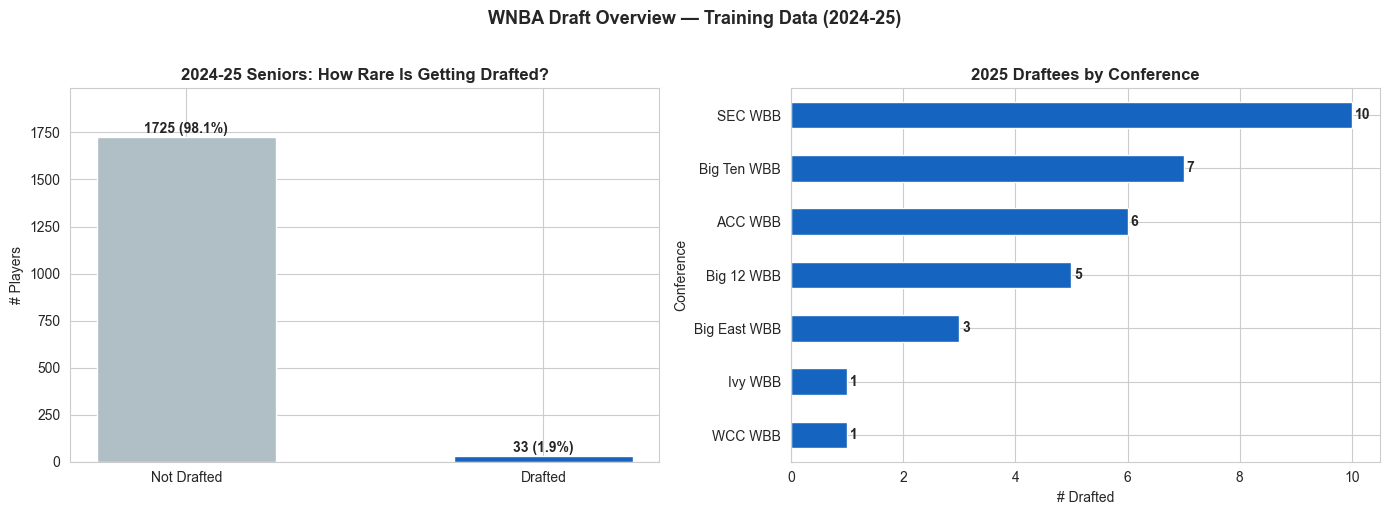

Draft rate: 33/1758 seniors (1.9%)


In [64]:
sns.set_style('whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

total_sr  = len(player_stats_2025)
n_drafted = player_stats_2025['Drafted'].sum()
n_not     = total_sr - n_drafted

ax = axes[0]
bars = ax.bar(['Not Drafted', 'Drafted'], [n_not, n_drafted],
              color=['#B0BEC5', '#1565C0'], edgecolor='white', width=0.5)
ax.set_title('2024-25 Seniors: How Rare Is Getting Drafted?', fontweight='bold')
ax.set_ylabel('# Players')
ax.set_ylim(0, n_not * 1.15)
for bar, val, pct in zip(bars, [n_not, n_drafted], [n_not/total_sr, n_drafted/total_sr]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{val} ({pct:.1%})', ha='center', va='bottom', fontweight='bold')

ax2 = axes[1]
conf_counts = (player_stats_2025[player_stats_2025['Drafted'] == 1]['Conference']
               .value_counts().head(8))
conf_counts.plot(kind='barh', ax=ax2, color='#1565C0')
ax2.set_title('2025 Draftees by Conference', fontweight='bold')
ax2.set_xlabel('# Drafted')
ax2.invert_yaxis()
for i, v in enumerate(conf_counts):
    ax2.text(v + 0.05, i, str(v), va='center', fontweight='bold')

plt.suptitle('WNBA Draft Overview — Training Data (2024-25)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("data/viz/draft_overview.png")
plt.show()
print(f'Draft rate: {n_drafted}/{total_sr} seniors ({n_drafted/total_sr:.1%})')

In [26]:
def feature_engineering(dframe):
    df = dframe.copy()

    def height_to_inches(h):
        try:
            ft, inch = str(h).split('-')
            return int(ft) * 12 + int(inch)
        except Exception:
            return np.nan

    df['height_in'] = df['Height'].apply(height_to_inches)

    class_map = {'FR': 1, 'So': 2, 'SO': 2, 'JR': 3, 'Jr': 3, 'SR': 4, 'Sr': 4, 'GR': 5, 'Gr': 5}
    df['class_ord'] = df['Class'].map(class_map).fillna(2)

    per_game = {'PTS': 'pts_pg', 'TRB': 'trb_pg', 'AST': 'ast_pg', 'STL': 'stl_pg',
                'BLK': 'blk_pg', 'TOV': 'tov_pg', 'FGA': 'fga_pg', 'FTA': 'fta_pg', 'MP': 'mp_pg'}
    for raw, feat in per_game.items():
        df[feat] = df[raw] / df['G'].replace(0, np.nan)

    mp_safe = df['MP'].replace(0, np.nan)
    per40 = {'PTS': 'pts_p40', 'TRB': 'trb_p40', 'AST': 'ast_p40', 'STL': 'stl_p40',
             'BLK': 'blk_p40', 'TOV': 'tov_p40', 'ORB': 'orb_p40', 'DRB': 'drb_p40'}
    for raw, feat in per40.items():
        df[feat] = df[raw] / mp_safe * 40

    df['ast_tov_ratio']     = df['AST'] / df['TOV'].replace(0, np.nan)
    df['stl_blk_pg']        = df['stl_pg'] + df['blk_pg']
    df['stl_blk_tov_ratio'] = df['stl_blk_pg'] / df['tov_pg'].replace(0, np.nan)
    df['pts_per_fga']       = df['PTS'] / df['FGA'].replace(0, np.nan)
    df['ft_rate']           = df['FTA'] / df['FGA'].replace(0, np.nan)
    df['non3_fg_pct']       = df['2P'] / df['2PA'].replace(0, np.nan)
    df['rim_rate']          = df['2PA'] / df['FGA'].replace(0, np.nan)
    df['games_started_pct'] = df['GS'] / df['G'].replace(0, np.nan)

    df['off_composite']  = df['PER'] + df['OBPM'] + df['USG%'] / 10
    df['def_composite']  = df['DBPM'] + df['STL%'] + df['BLK%']
    df['bpm_gap']        = df['OBPM'] - df['DBPM']
    df['ws_per_game']    = df['WS'] / df['G'].replace(0, np.nan)
    df['versatility']    = df['pts_p40'] + df['trb_p40'] + df['ast_p40']
    df['scoring_load']   = df['USG%'] * df['TS%']
    df['prod_composite'] = (
        df['pts_pg'] * 1.0 + df['trb_pg'] * 1.2 + df['ast_pg'] * 1.5 +
        df['stl_pg'] * 2.0 + df['blk_pg'] * 2.0 - df['tov_pg'] * 1.5
    )

    # Fix #4: include alternate conference name spellings (MWC WBB = Mountain West)
    power_conf = {'ACC WBB', 'Big Ten WBB', 'SEC WBB', 'Big 12 WBB', 'Pac-12 WBB'}
    high_conf  = {'Big East WBB', 'American Athletic WBB', 'Mountain West WBB',
                  'MWC WBB', 'Atlantic 10 WBB'}
    mid_conf   = {'Missouri Valley WBB', 'WAC WBB', 'Sun Belt WBB',
                  'Conference USA WBB', 'WCC WBB'}

    def conf_tier(c):
        if c in power_conf: return 3
        if c in high_conf:  return 2
        if c in mid_conf:   return 1
        return 0

    df['conf_tier']   = df['Conference'].apply(conf_tier)
    df['bpm_sos_adj'] = df['BPM'] * (1 + df['sos'])

    pct_cols = ['BPM', 'WS', 'WS/40', 'PER', 'TS%', 'prod_composite',
                'versatility', 'off_composite', 'def_composite', 'bpm_sos_adj']
    for col in pct_cols:
        df[f'{col}_pct'] = df[col].rank(pct=True)
    return df

In [27]:
df = feature_engineering(player_stats_2025)

mp_thresh = df['mp_pg'].mean()
g_thresh  = df['G'].mean()

# Fix #3: show drafted players that would be silently dropped by the minutes filter
would_drop    = df[(df['mp_pg'] < mp_thresh) | (df['G'] < g_thresh)]
drafted_dropped = would_drop[would_drop['Drafted'] == 1]
print(f'Drafted players below minutes/games threshold: {len(drafted_dropped)}')
if len(drafted_dropped):
    print(drafted_dropped[['Player', 'Team', 'mp_pg', 'G']])

# Always keep drafted players; filter only undrafted low-minute players
df = df[((df['mp_pg'] >= mp_thresh) & (df['G'] >= g_thresh)) | (df['Drafted'] == 1)]
print(f'\nTraining rows: {len(df)}  |  Drafted: {df["Drafted"].sum()}')

Drafted players below minutes/games threshold: 4
               Player                               Team      mp_pg     G
256   Aicha Coulibaly           Texas A&M Aggies Women's  28.315789  19.0
419      Sania Feagin   South Carolina Gamecocks Women's  19.794872  39.0
692    Maddy Westbeld  Notre Dame Fighting Irish Women's  22.571429  21.0
1473   Aubrey Griffin              UConn Huskies Women's  11.125000  16.0

Training rows: 757  |  Drafted: 33


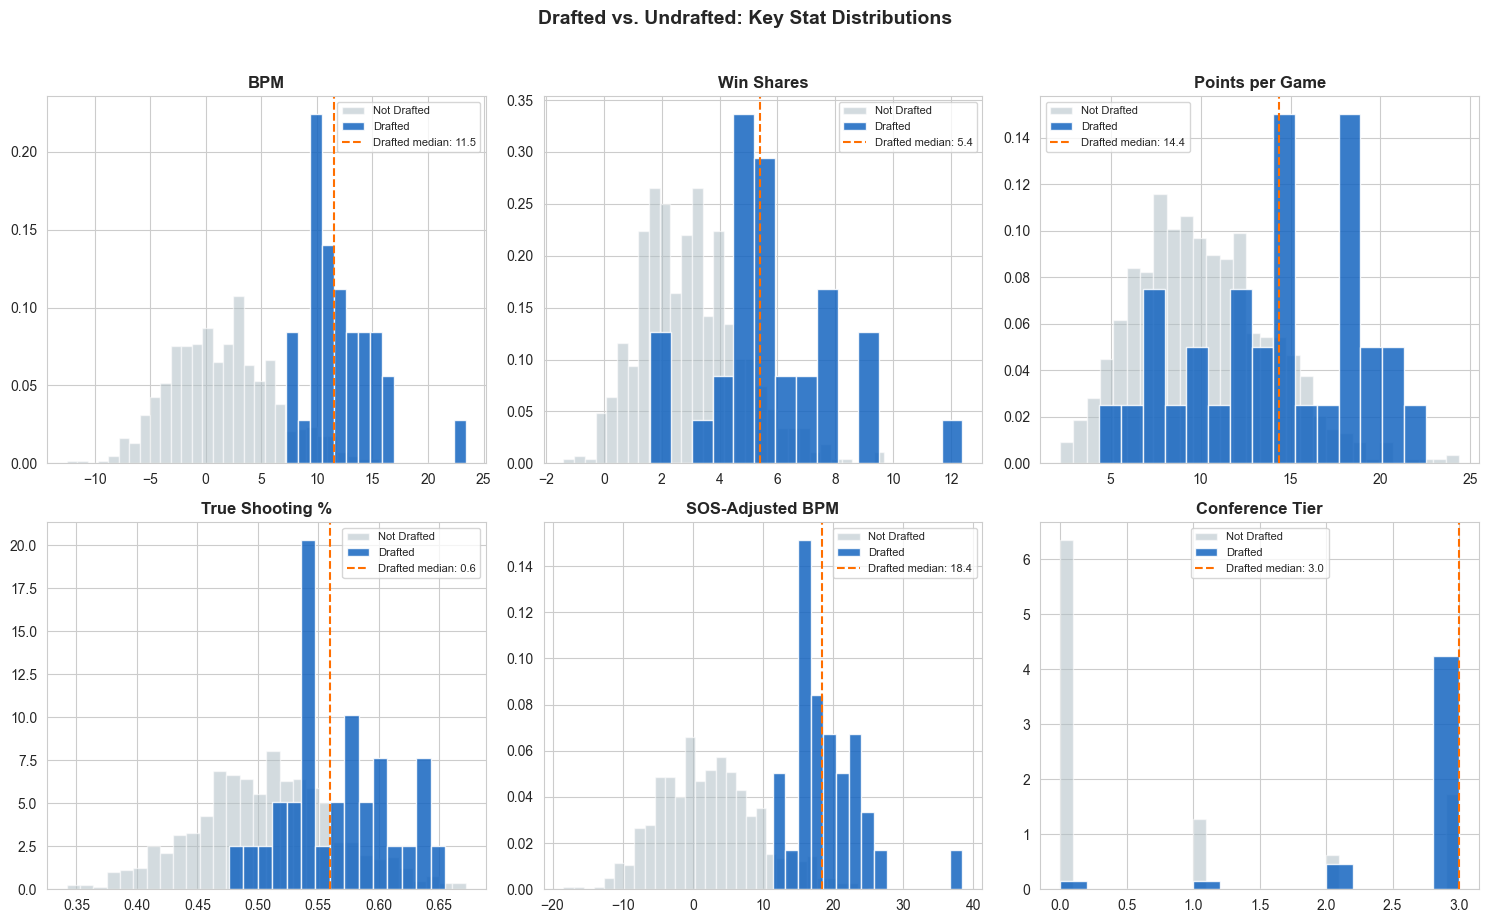

In [65]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
plot_cols   = ['BPM', 'WS', 'pts_pg', 'TS%', 'bpm_sos_adj', 'conf_tier']
plot_titles = ['BPM', 'Win Shares', 'Points per Game', 'True Shooting %',
               'SOS-Adjusted BPM', 'Conference Tier']

for ax, col, title in zip(axes.flat, plot_cols, plot_titles):
    not_d = df[df['Drafted'] == 0][col].dropna()
    d     = df[df['Drafted'] == 1][col].dropna()
    ax.hist(not_d, bins=30, alpha=0.55, color='#B0BEC5', label='Not Drafted', density=True)
    ax.hist(d,     bins=15, alpha=0.85, color='#1565C0', label='Drafted',     density=True)
    ax.axvline(d.median(), color='#FF6F00', linestyle='--', linewidth=1.5,
               label=f'Drafted median: {d.median():.1f}')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Drafted vs. Undrafted: Key Stat Distributions',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("data/viz/stat_distributions.png")
plt.show()

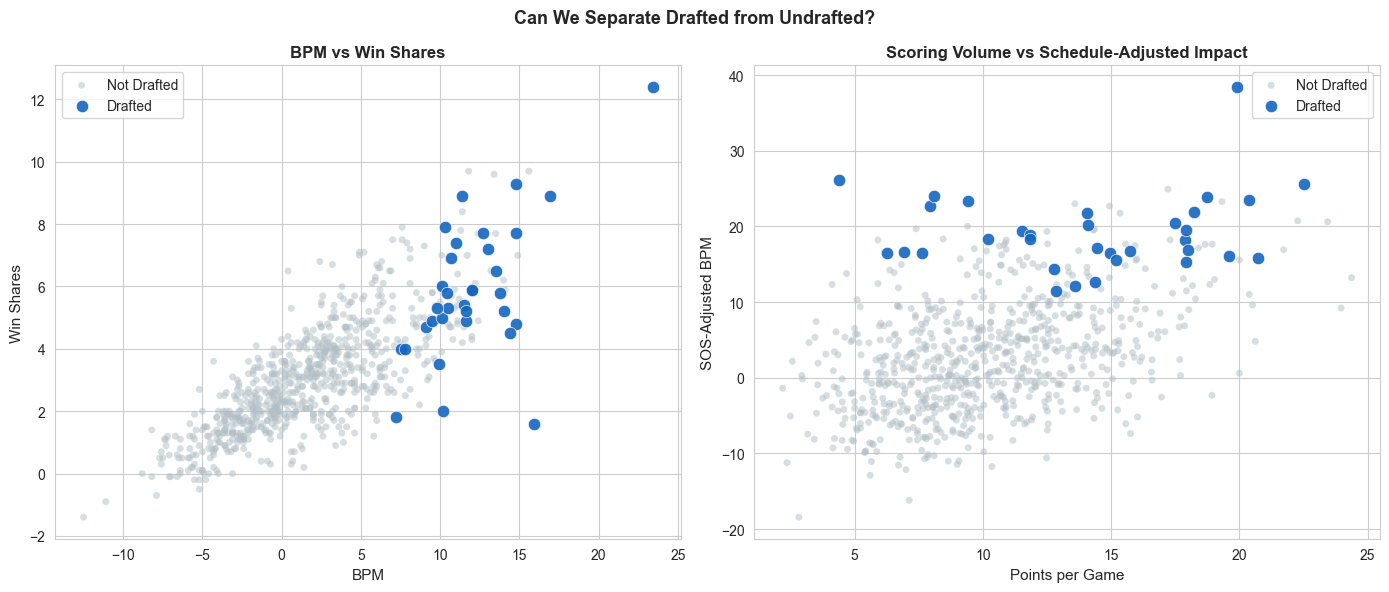

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
d_mask  = df['Drafted'] == 1
nd_mask = ~d_mask

ax = axes[0]
ax.scatter(df.loc[nd_mask, 'BPM'], df.loc[nd_mask, 'WS'],
           c='#B0BEC5', s=25, alpha=0.5, label='Not Drafted', edgecolors='none')
ax.scatter(df.loc[d_mask, 'BPM'], df.loc[d_mask, 'WS'],
           c='#1565C0', s=80, alpha=0.9, label='Drafted',
           edgecolors='white', linewidths=0.5, zorder=5)
ax.set_xlabel('BPM', fontsize=11)
ax.set_ylabel('Win Shares', fontsize=11)
ax.set_title('BPM vs Win Shares', fontweight='bold')
ax.legend()

ax2 = axes[1]
ax2.scatter(df.loc[nd_mask, 'pts_pg'], df.loc[nd_mask, 'bpm_sos_adj'],
            c='#B0BEC5', s=25, alpha=0.5, label='Not Drafted', edgecolors='none')
ax2.scatter(df.loc[d_mask, 'pts_pg'], df.loc[d_mask, 'bpm_sos_adj'],
            c='#1565C0', s=80, alpha=0.9, label='Drafted',
            edgecolors='white', linewidths=0.5, zorder=5)
ax2.set_xlabel('Points per Game', fontsize=11)
ax2.set_ylabel('SOS-Adjusted BPM', fontsize=11)
ax2.set_title('Scoring Volume vs Schedule-Adjusted Impact', fontweight='bold')
ax2.legend()

plt.suptitle('Can We Separate Drafted from Undrafted?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("data/viz/scatter_plots_by_drafted.png")
plt.show()

In [30]:
drop_raw = ['FG','FGA','FT','FTA','3P','3PA','2P','2PA','ORB','DRB','TRB',
            'AST','STL','BLK','TOV','PF','PTS','MP','PProd','#']
feature_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                if c != 'Drafted' and c not in drop_raw]

corr = df[feature_cols + ['Drafted']].corr()['Drafted'].abs().sort_values(ascending=False)
final_feature_cols = corr[corr > 0.05].index.tolist()
final_feature_cols.remove('Drafted')
print(f'Selected {len(final_feature_cols)} features')
print(corr.head(15).to_string())

Selected 62 features
Drafted            1.000000
bpm_sos_adj        0.436700
BPM                0.422892
OBPM               0.379640
DBPM               0.371783
sos                0.365877
conf_tier          0.334266
off_composite      0.323576
WS/40              0.321008
WS                 0.314043
ws_per_game        0.308479
OWS                0.306829
bpm_sos_adj_pct    0.303571
BPM_pct            0.302037
def_composite      0.298393


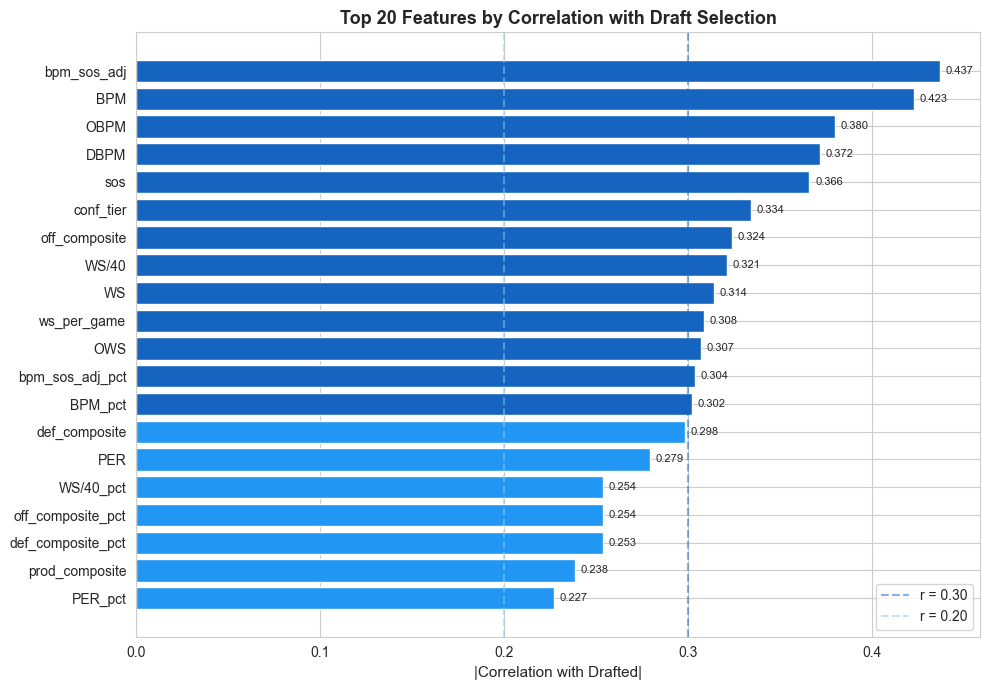

In [67]:
top_corr   = corr.drop('Drafted').head(20)
bar_colors = ['#1565C0' if v >= 0.3 else '#2196F3' if v >= 0.2 else '#90CAF9'
              for v in top_corr.values]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(range(len(top_corr)), top_corr.values, color=bar_colors)
ax.set_yticks(range(len(top_corr)))
ax.set_yticklabels(top_corr.index)
ax.invert_yaxis()
ax.set_xlabel('|Correlation with Drafted|', fontsize=11)
ax.set_title('Top 20 Features by Correlation with Draft Selection',
             fontweight='bold', fontsize=13)
ax.axvline(0.3, color='#1565C0', linestyle='--', alpha=0.5, label='r = 0.30')
ax.axvline(0.2, color='#90CAF9', linestyle='--', alpha=0.5, label='r = 0.20')
ax.legend()
for bar, val in zip(bars, top_corr.values):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig("data/viz/top_corr_features.png")
plt.show()

In [32]:
X = df[final_feature_cols]
y = df['Drafted']

imputer = SimpleImputer(strategy='median')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=final_feature_cols, index=X.index)

X_train, X_test, y_train, y_test = train_test_split(
    X_imp, y, test_size=0.2, random_state=42, stratify=y
)

# Fix #5: compute spw separately for train split (evaluation) vs full data (final fit)
spw_train = (y_train == 0).sum() / y_train.sum()
spw_all   = (y == 0).sum() / y.sum()
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f'Train: {len(y_train):,}  |  drafted: {y_train.sum()}  |  imbalance: {spw_train:.0f}:1')
print(f'Test:  {len(y_test):,}   |  drafted: {y_test.sum()}')
print(f'spw (train split): {spw_train:.1f}  |  spw (all data): {spw_all:.1f}')

Train: 605  |  drafted: 26  |  imbalance: 22:1
Test:  152   |  drafted: 7
spw (train split): 22.3  |  spw (all data): 21.9


In [33]:
def evaluate_model(clf, X_train, y_train, X_test, y_test, name=''):
    clf.fit(X_train, y_train)
    proba = clf.predict_proba(X_test)[:, 1]
    roc = roc_auc_score(y_test, proba)
    pr  = average_precision_score(y_test, proba)
    print(f'{name}: ROC AUC={roc:.3f}  PR AUC={pr:.3f}')
    return {'name': name, 'clf': clf, 'roc_auc': roc, 'pr_auc': pr}

xgb_clf = XGBClassifier(
    eval_metric='logloss', random_state=42, scale_pos_weight=spw_train,
    n_estimators=500, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8,
)
lgbm_clf = LGBMClassifier(
    random_state=42, scale_pos_weight=spw_train, min_child_samples=5,
    n_estimators=500, learning_rate=0.05, num_leaves=31,
    subsample=0.8, colsample_bytree=0.8, verbose=-1,
)
rf_clf = RandomForestClassifier(
    random_state=42, class_weight='balanced', n_estimators=500,
    max_depth=6, min_samples_leaf=2,
)

print('Hold-out test set performance:')
results = [
    evaluate_model(xgb_clf,  X_train, y_train, X_test, y_test, 'XGBoost'),
    evaluate_model(lgbm_clf, X_train, y_train, X_test, y_test, 'LightGBM'),
    evaluate_model(rf_clf,   X_train, y_train, X_test, y_test, 'Random Forest'),
]

Hold-out test set performance:
XGBoost: ROC AUC=0.990  PR AUC=0.824
LightGBM: ROC AUC=0.979  PR AUC=0.717
Random Forest: ROC AUC=0.970  PR AUC=0.595


In [34]:
# Fix #2: 5-fold CV gives more reliable metrics than a single 80/20 split
# With only ~29 positives, hold-out metrics swing wildly depending on the random split.
print('5-Fold Cross-Validation (out-of-fold predictions on full training set):\n')
for r in results:
    oof = cross_val_predict(r['clf'], X_imp, y, cv=cv5, method='predict_proba')[:, 1]
    r['cv_roc_auc'] = roc_auc_score(y, oof)
    r['cv_pr_auc']  = average_precision_score(y, oof)
    print(f"{r['name']}: CV ROC AUC={r['cv_roc_auc']:.3f}  CV PR AUC={r['cv_pr_auc']:.3f}")

results_df = (pd.DataFrame(results)
              .drop(columns='clf')
              .sort_values('cv_pr_auc', ascending=False)
              .reset_index(drop=True))
display(results_df)

5-Fold Cross-Validation (out-of-fold predictions on full training set):

XGBoost: CV ROC AUC=0.966  CV PR AUC=0.509
LightGBM: CV ROC AUC=0.962  CV PR AUC=0.453
Random Forest: CV ROC AUC=0.965  CV PR AUC=0.555


,name,roc_auc,pr_auc,cv_roc_auc,cv_pr_auc
0,Random Forest,0.970443,0.594505,0.964549,0.555202
1,XGBoost,0.990148,0.823902,0.966056,0.509024
2,LightGBM,0.979310,0.716667,0.961996,0.453003


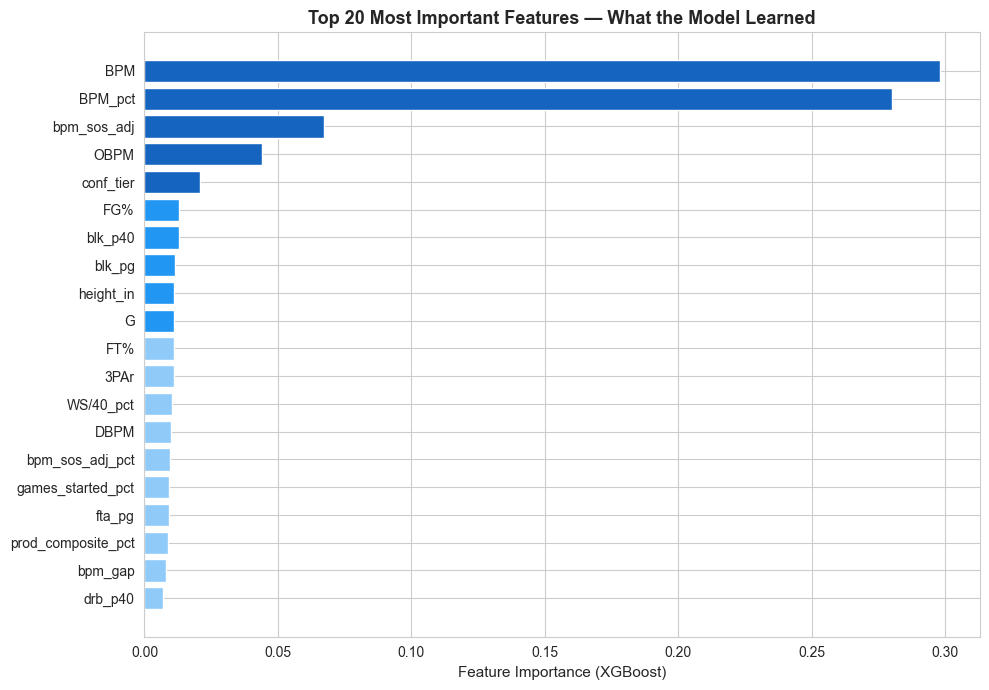

In [68]:
importance = (pd.Series(xgb_clf.feature_importances_, index=final_feature_cols)
              .sort_values(ascending=False)
              .head(20))

cutoff_top5  = importance.iloc[4]
cutoff_top10 = importance.iloc[9]
bar_colors   = ['#1565C0' if v >= cutoff_top5 else '#2196F3' if v >= cutoff_top10 else '#90CAF9'
                for v in importance.values]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(range(len(importance)), importance.values, color=bar_colors)
ax.set_yticks(range(len(importance)))
ax.set_yticklabels(importance.index)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance (XGBoost)', fontsize=11)
ax.set_title('Top 20 Most Important Features — What the Model Learned',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig("data/viz/feature_importance.png")
plt.show()

In [36]:
# Fix #5 + #6: refit all three models on full data using spw_all, then ensemble
xgb_final = XGBClassifier(
    eval_metric='logloss', random_state=42, scale_pos_weight=spw_all,
    n_estimators=500, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8,
)
lgbm_final = LGBMClassifier(
    random_state=42, scale_pos_weight=spw_all, min_child_samples=5,
    n_estimators=500, learning_rate=0.05, num_leaves=31,
    subsample=0.8, colsample_bytree=0.8, verbose=-1,
)
rf_final = RandomForestClassifier(
    random_state=42, class_weight='balanced', n_estimators=500,
    max_depth=6, min_samples_leaf=2,
)

for clf in [xgb_final, lgbm_final, rf_final]:
    clf.fit(X_imp, y)

print('All three models fit on full training data.')

All three models fit on full training data.


,Player,Team,Draft_Prob,XGB_Prob,LGBM_Prob,RF_Prob
364,Ta'Niya Latson,South Carolina Gamecocks Women's,0.974183,0.996237,0.998938,0.927375
365,Raven Johnson,South Carolina Gamecocks Women's,0.961694,0.998017,0.999201,0.887865
854,Flau'jae Johnson,LSU Lady Tigers Women's,0.958149,0.940228,0.992134,0.942085
727,Cotie McMahon,Ole Miss Rebels Women's,0.917376,0.989649,0.999913,0.762564
229,Olivia Miles,TCU Horned Frogs Women's,0.914163,0.948831,0.984717,0.808940
363,Madina Okot,South Carolina Gamecocks Women's,0.912278,0.974131,0.998863,0.763838
160,Angela Dugalić,UCLA Bruins Women's,0.911829,0.904473,0.999005,0.832010
1200,Azzi Fudd,UConn Huskies Women's,0.910812,0.956928,0.999153,0.776356
896,Tonie Morgan,Kentucky Wildcats Women's,0.909484,0.998317,0.999895,0.730239
625,Indya Nivar,UNC Tar Heels Women's,0.836083,0.916812,0.966949,0.624489


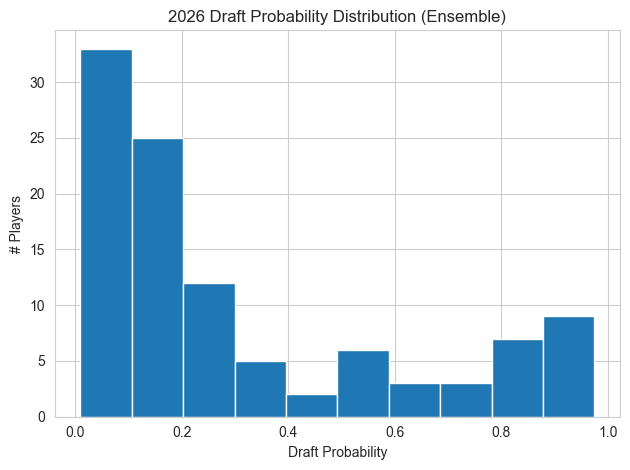

In [69]:
player_stats_2026 = pd.read_csv('./data/Copy of WBB Data - ncaa2526.csv')
player_stats_2026 = player_stats_2026[player_stats_2026['Class'] == 'SR'].copy()

team_stats_2026 = get_team_stats(41098)
team_cols_2026  = ['fullName', 'sos', 'netRanking', 'netRtgAdjGap', 'netRtgAdj',
                   'ortgAdjGap', 'ortgAdj', 'drtgAdjGap', 'drtgAdj']
player_stats_2026 = merge_team_stats(player_stats_2026, team_stats_2026, team_cols_2026)

df2 = feature_engineering(player_stats_2026)
df2 = df2[(df2['mp_pg'] >= df2['mp_pg'].mean()) & (df2['G'] >= df2['G'].mean())]

X2026 = pd.DataFrame(
    imputer.transform(df2[final_feature_cols]),
    columns=final_feature_cols,
    index=df2.index,
)

# Fix #6: ensemble — average probabilities from all three models
p_xgb  = xgb_final.predict_proba(X2026)[:, 1]
p_lgbm = lgbm_final.predict_proba(X2026)[:, 1]
p_rf   = rf_final.predict_proba(X2026)[:, 1]
df2['Draft_Prob']  = (p_xgb + p_lgbm + p_rf) / 3
df2['XGB_Prob']    = p_xgb
df2['LGBM_Prob']   = p_lgbm
df2['RF_Prob']     = p_rf

top30 = df2[['Player', 'Team', 'Draft_Prob', 'XGB_Prob', 'LGBM_Prob', 'RF_Prob']].sort_values(
    'Draft_Prob', ascending=False
).head(30)
display(top30)

df2[df2['Draft_Prob'] >= 0.01]['Draft_Prob'].hist(bins=10)
plt.title('2026 Draft Probability Distribution (Ensemble)')
plt.xlabel('Draft Probability')
plt.ylabel('# Players')
plt.tight_layout()
plt.savefig("data/viz/draft_probability_distribution.png")
plt.show()

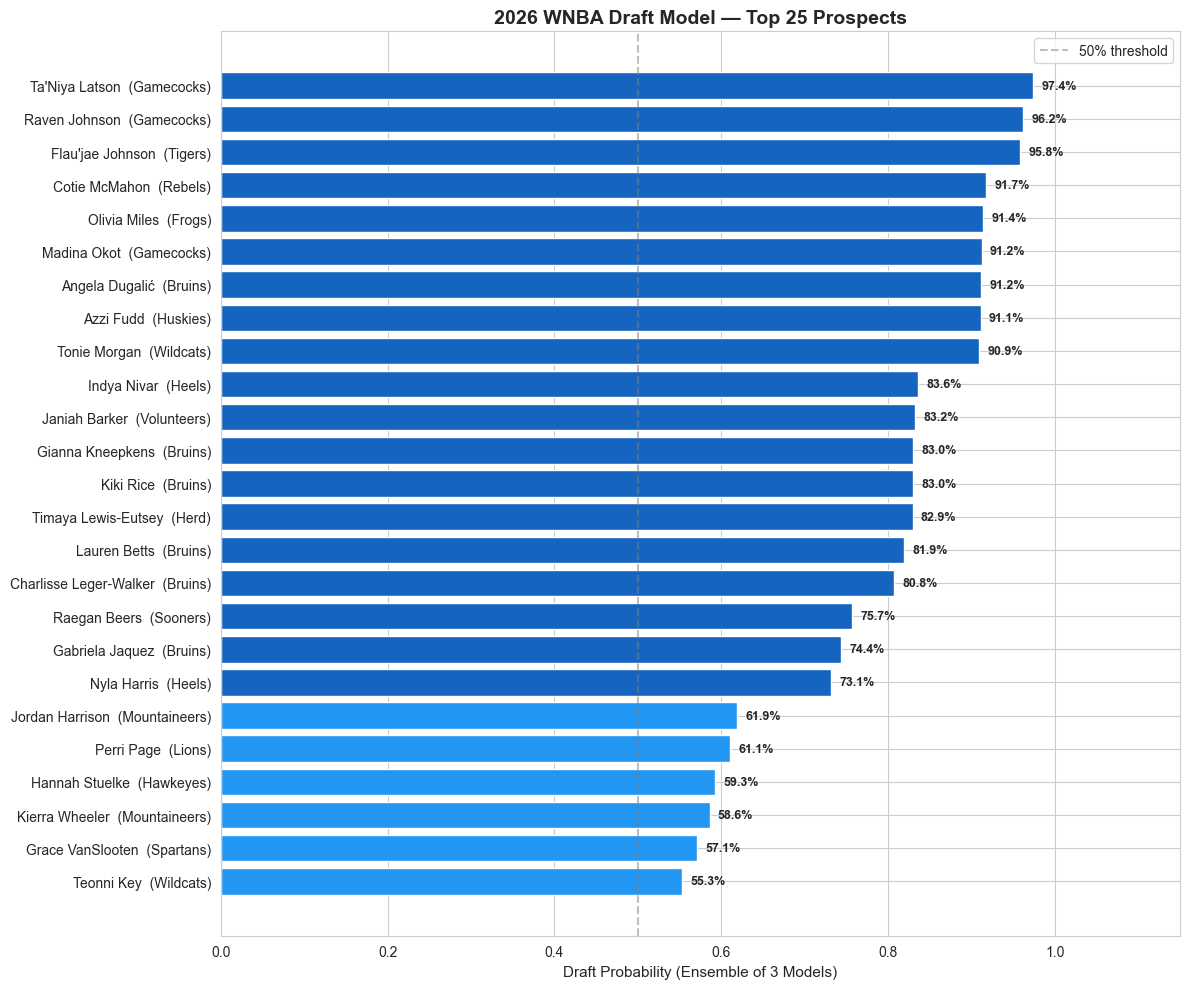

In [70]:
top25 = (df2[['Player', 'Team', 'Draft_Prob']]
         .sort_values('Draft_Prob', ascending=False)
         .head(25).reset_index(drop=True))
# Use the team mascot (second-to-last word before "Women's") as a short label
top25['Label'] = top25['Player'] + '  (' + top25['Team'].str.split().str[-2] + ')'

bar_colors = ['#1565C0' if p >= 0.7 else '#2196F3' if p >= 0.4 else '#90CAF9'
              for p in top25['Draft_Prob']]

fig, ax = plt.subplots(figsize=(12, 10))
bars = ax.barh(range(len(top25)), top25['Draft_Prob'], color=bar_colors, edgecolor='white')
ax.set_yticks(range(len(top25)))
ax.set_yticklabels(top25['Label'], fontsize=10)
ax.invert_yaxis()
ax.set_xlim(0, 1.15)
ax.set_xlabel('Draft Probability (Ensemble of 3 Models)', fontsize=11)
ax.set_title('2026 WNBA Draft Model — Top 25 Prospects',
             fontweight='bold', fontsize=14)
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.5, label='50% threshold')
ax.legend()
for bar, prob in zip(bars, top25['Draft_Prob']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{prob:.1%}', va='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig("data/viz/top_2026_prospects_from_ensemble.png")
plt.show()

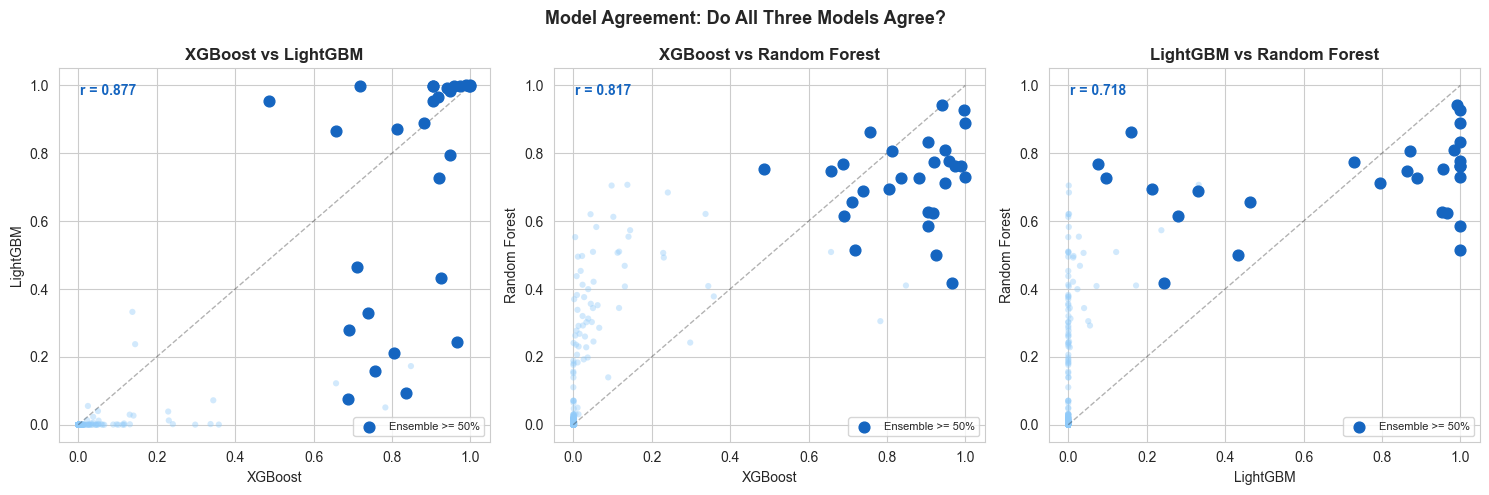

In [71]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
pairs  = [('XGB_Prob', 'LGBM_Prob'), ('XGB_Prob', 'RF_Prob'), ('LGBM_Prob', 'RF_Prob')]
labels = [('XGBoost', 'LightGBM'), ('XGBoost', 'Random Forest'), ('LightGBM', 'Random Forest')]

for ax, (xc, yc), (xl, yl) in zip(axes, pairs, labels):
    ax.scatter(df2[xc], df2[yc], alpha=0.4, s=20, color='#90CAF9', edgecolors='none')
    top_mask = df2['Draft_Prob'] >= 0.5
    ax.scatter(df2.loc[top_mask, xc], df2.loc[top_mask, yc],
               color='#1565C0', s=60, zorder=5, label='Ensemble >= 50%')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=1)
    ax.set_xlabel(xl, fontsize=10)
    ax.set_ylabel(yl, fontsize=10)
    ax.set_title(f'{xl} vs {yl}', fontweight='bold')
    r = df2[xc].corr(df2[yc])
    ax.text(0.05, 0.93, f'r = {r:.3f}', transform=ax.transAxes,
            fontsize=10, color='#1565C0', fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Model Agreement: Do All Three Models Agree?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("data/viz/model_agreement_scatter.png")
plt.show()

In [40]:
df2['Pred_Drafted'] = np.where(df2['Draft_Prob'] >= 0.5, 1, 0)

In [41]:
df2[df2['Pred_Drafted'] == 1][['Player', 'Team', 'Draft_Prob']].sort_values('Draft_Prob', ascending=False)

,Player,Team,Draft_Prob
364,Ta'Niya Latson,South Carolina Gamecocks Women's,0.974183
365,Raven Johnson,South Carolina Gamecocks Women's,0.961694
854,Flau'jae Johnson,LSU Lady Tigers Women's,0.958149
727,Cotie McMahon,Ole Miss Rebels Women's,0.917376
229,Olivia Miles,TCU Horned Frogs Women's,0.914163
363,Madina Okot,South Carolina Gamecocks Women's,0.912278
160,Angela Dugalić,UCLA Bruins Women's,0.911829
1200,Azzi Fudd,UConn Huskies Women's,0.910812
896,Tonie Morgan,Kentucky Wildcats Women's,0.909484
625,Indya Nivar,UNC Tar Heels Women's,0.836083


In [58]:
player_lookup_df = pd.read_csv('./data/player_lookup.csv')

In [59]:
player_lookup_df.drop(columns=['draft_probability'], inplace=True)

In [60]:
player_lookup_df = pd.merge(player_lookup_df, df2[['Player', 'Draft_Prob']], left_on='player_name', right_on='Player', how='inner')

In [61]:
player_lookup_df

,player_name,team,class_year,position,games_played,archetype_id,archetype_name,proj_salary_low,proj_salary_mid,proj_salary_high,...,fg3_pct,ft_pct,ast_pct,reb_pct,blk_per_game,stl_per_game,usg_pct,ts_pct,Player,Draft_Prob
0,Casey Santoro,Youngstown State Penguins Women's,SR,G,35.0,2,High-Volume Wing/Guard,547779,644446,741112,...,0.301,0.808,0.184,0.086,0.1,1.1,0.197,0.502,Casey Santoro,0.000020
1,Savannah White,Xavier Musketeers Women's,SR,F,29.0,3,Interior Specialist,463907,545773,627639,...,0.095,0.521,0.177,0.137,1.4,1.5,0.165,0.470,Savannah White,0.000132
2,Malene Pedersen,Wyoming Cowgirls Women's,SR,G,29.0,2,High-Volume Wing/Guard,644288,757986,871684,...,0.340,0.867,0.188,0.071,0.1,0.6,0.288,0.551,Malene Pedersen,0.005438
3,Henna Sandvik,Wyoming Cowgirls Women's,SR,G,30.0,1,Bench Guard/Wing,522662,614897,707131,...,0.318,0.676,0.190,0.076,0.7,0.4,0.214,0.475,Henna Sandvik,0.000087
4,Logann Alvar,Wyoming Cowgirls Women's,SR,F,30.0,1,Bench Guard/Wing,437845,515111,592378,...,0.242,0.810,0.041,0.087,0.2,0.5,0.174,0.471,Logann Alvar,0.000200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
612,Ta'Mia Scott,Alabama Crimson Tide Women's,SR,G,35.0,4,Efficient Role Player,507328,596856,686385,...,0.374,0.600,0.093,0.071,0.9,0.9,0.197,0.527,Ta'Mia Scott,0.117320
613,Karly Weathers,Alabama Crimson Tide Women's,SR,G,35.0,2,High-Volume Wing/Guard,498413,586368,674323,...,0.358,0.710,0.196,0.100,0.4,1.8,0.151,0.542,Karly Weathers,0.206729
614,Milahnie Perry,Air Force Falcons Women's,SR,G,33.0,2,High-Volume Wing/Guard,649871,764554,879237,...,0.284,0.738,0.242,0.069,0.2,1.4,0.319,0.465,Milahnie Perry,0.001373
615,Emily Adams,Air Force Falcons Women's,SR,F,35.0,0,Elite Two-Way Big,502867,591608,680349,...,0.625,0.721,0.107,0.118,0.3,1.0,0.235,0.470,Emily Adams,0.000071


In [62]:
player_lookup_df.to_csv('final_player_lookup.csv', index=False)